In [17]:
import os
import sys
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)

from utils.paths import DESPIKED_DATA_DIRECTORY
from utils.import_data import import_acropolis_site_data
from config.sites_deloyment_times import deployment_times

assert(os.path.exists(DESPIKED_DATA_DIRECTORY))


### Overall strategy:
1. Choose a calibration frequency step.
2. Try all possible offsets for that frequency.
3. Apply sparse calibration points.
4. Interpolate slope and intercept.
5. Correct the GMP343 signal.
6. Compare against the reference (all calibration days) using RMSE / MAE.
7. Average performance across offsets.

In [18]:
df_site

datetime,system_id,system_name,gmp343_corrected,gmp343_edge_corrected,gmp343_temperature,sht45_humidity,h2o_v%,bme280_pressure,enclosure_bme280_pressure,wxt532_speed_avg,wxt532_direction_avg,gmp343_dry,slope,intercept,gmp343_edge_dry,cal_gmp343_slope,cal_gmp343_intercept,Flag
"datetime[μs, UTC]",i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
2025-02-18 00:00:00 UTC,6,"""acropolis-6""",470.39,469.933333,27.883333,13.546667,0.540506,941.696667,957.99,0.6,107.6,454.556909,1.029318,3.458734,454.516667,1.03,2.91,"""U"""
2025-02-18 00:00:00 UTC,3,"""acropolis-3""",470.18,470.35,42.633333,6.858333,0.6179,942.005,959.4,null,null,496.970783,0.980614,-17.432537,496.933333,1.0,-25.48,"""U"""
2025-02-18 00:01:00 UTC,3,"""acropolis-3""",466.63,466.8,42.65,6.9,0.62231,941.833333,959.41,null,null,493.370291,0.980614,-17.432537,493.333333,1.0,-25.48,"""U"""
2025-02-18 00:02:00 UTC,3,"""acropolis-3""",458.89,458.983333,42.633333,6.833333,0.61531,942.521667,959.41,null,null,485.520793,0.980614,-17.432537,485.55,1.0,-25.48,"""U"""
2025-02-18 00:03:00 UTC,3,"""acropolis-3""",458.46,458.55,42.6,6.723333,0.604897,941.67,959.38,null,null,485.084261,0.980614,-17.432537,485.15,1.0,-25.48,"""U"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-30 22:56:00 UTC,3,"""acropolis-3""",462.02,462.183333,47.6,10.658133,1.263815,923.818333,954.76,null,null,477.889639,1.002442,-16.508635,477.85,0.9994,-15.6,"""U"""
2025-10-30 22:57:00 UTC,3,"""acropolis-3""",459.03,459.216667,47.616667,10.687367,1.268183,923.938333,954.76,null,null,474.906009,1.002442,-16.508635,474.883333,0.9994,-15.6,"""U"""
2025-10-30 22:58:00 UTC,3,"""acropolis-3""",460.53,460.733333,47.616667,10.658433,1.264512,924.111667,954.79,null,null,476.407565,1.002442,-16.508635,476.433333,0.9994,-15.6,"""U"""


In [ ]:
# use TUMR for v1, and TUMRv2 for v2

df_site = import_acropolis_site_data(target_directory=DESPIKED_DATA_DIRECTORY,
                                            deployment_times=deployment_times,
                                            site_name="TUMR")

# define UTC timezones to filter the data to the time range of interest
start_time =  datetime(2025, 2, 18, 1, 0, 0).astimezone(timezone.utc)
end_time = datetime(2025, 10, 31, 0, 0, 0).astimezone(timezone.utc)

df_site = df_site.filter(pl.col("datetime").is_between(start_time, end_time))

In [27]:
# create a copy of the data to have a reference to compare to
df_reference = df_site.select(pl.col("datetime"), pl.col("gmp343_corrected"), pl.col("Flag")) \
    .filter(pl.col("Flag") == "U") \
    .group_by_dynamic("datetime", every="1h") \
    .agg(pl.col("gmp343_corrected").mean().alias("ref_corrected"))

In [28]:
# filter for slope, intercept
# filter by first appearance of each unique value

df_cal_times = df_site.select(pl.col("datetime"), pl.col("slope"), pl.col("intercept")) \
    .unique(subset=["slope", "intercept"],keep="first",maintain_order=True)

In [29]:
df_data = df_site.select(pl.col("datetime"), pl.col("gmp343_dry"), pl.col("Flag")) \
    .filter(pl.col("Flag") == "U")

In [30]:
# Filter calibration frequency data to only include every other row to module frequency
def filter_calibration_frequency(df_cal_times: pl.DataFrame, frequency: int, offset: int = 0) -> pl.DataFrame:
    assert frequency > 0, "Frequency must be a positive integer"
    assert offset >= 0, "Offset must be a non-negative integer"
    assert offset < frequency, "Offset must be less than frequency"
    
    return df_cal_times.with_row_index("idx") \
        .filter(pl.col("idx") % frequency == offset) \
        .drop("idx")

In [31]:
filter_calibration_frequency(df_cal_times, frequency=1, offset=0)

datetime,slope,intercept
"datetime[μs, UTC]",f64,f64
2025-02-18 00:00:00 UTC,1.029318,3.458734
2025-02-18 00:00:00 UTC,0.980614,-17.432537
2025-02-21 02:36:00 UTC,0.991202,-22.166685
2025-02-25 02:37:00 UTC,0.988738,-20.02316
2025-03-01 02:36:00 UTC,0.988328,-19.601053
…,…,…
2025-10-11 01:37:00 UTC,1.010078,-19.600635
2025-10-15 01:37:00 UTC,0.999922,-14.95504
2025-10-19 01:37:00 UTC,0.997832,-14.231768


shape: (20, 7)
┌───────────┬───────────┬──────────┬───────────┬──────────┬──────────┬──────────┐
│ frequency ┆ rmse_mean ┆ rmse_std ┆ rmse_var  ┆ mae_mean ┆ mae_std  ┆ mae_var  │
│ ---       ┆ ---       ┆ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---      │
│ i64       ┆ f64       ┆ f64      ┆ f64       ┆ f64      ┆ f64      ┆ f64      │
╞═══════════╪═══════════╪══════════╪═══════════╪══════════╪══════════╪══════════╡
│ 1         ┆ 0.931827  ┆ null     ┆ null      ┆ 0.499561 ┆ null     ┆ null     │
│ 2         ┆ 4.088297  ┆ 4.347606 ┆ 18.901676 ┆ 1.552419 ┆ 1.316822 ┆ 1.73402  │
│ 3         ┆ 3.204749  ┆ 3.402912 ┆ 11.579809 ┆ 1.380396 ┆ 0.897796 ┆ 0.806038 │
│ 4         ┆ 4.321689  ┆ 6.215961 ┆ 38.638177 ┆ 2.40422  ┆ 3.123391 ┆ 9.755572 │
│ 5         ┆ 2.493806  ┆ 2.234691 ┆ 4.993844  ┆ 1.334994 ┆ 0.522786 ┆ 0.273305 │
│ …         ┆ …         ┆ …        ┆ …         ┆ …        ┆ …        ┆ …        │
│ 16        ┆ 4.249391  ┆ 4.177895 ┆ 17.454807 ┆ 3.215833 ┆ 2.783323 ┆ 7.746887 │
│

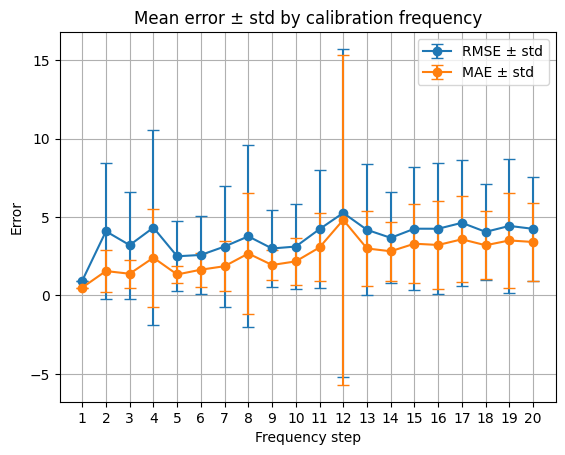

In [ ]:
max_frequency = 20
frequency_results = []

for frequency in range(1, max_frequency + 1):
    offset_results = []

    for offset in range(frequency):
        df_data_filtered = (
            df_data
            .join(
                filter_calibration_frequency(
                    df_cal_times,
                    frequency=frequency,
                    offset=offset,
                ),
                on="datetime",
                how="left",
            )
            .with_columns(
                pl.col(["slope", "intercept"]).interpolate()
            )
            .with_columns(
                pl.col("slope")
                .fill_null(strategy="forward")
                .fill_null(strategy="backward"),

                pl.col("intercept")
                .fill_null(strategy="forward")
                .fill_null(strategy="backward"),
            )
            .with_columns(
                gmp343_dry_corrected=(
                    pl.col("gmp343_dry") * pl.col("slope")
                    + pl.col("intercept")
                )
            )
            .group_by_dynamic("datetime", every="1h")
            .agg(
                pl.col("gmp343_dry_corrected")
                .mean()
                .alias("gmp343_corrected")
            )
        )

        error = pl.col("ref_corrected") - pl.col("gmp343_corrected")

        metrics = (
            df_reference
            .join(df_data_filtered, on="datetime", how="left")
            .select(
                frequency=pl.lit(frequency).cast(pl.Int64),
                offset=pl.lit(offset).cast(pl.Int64),
                rmse=error.pow(2).mean().sqrt(),
                mae=error.abs().mean(),
            )
        )

        offset_results.append(metrics)

    df_offset_metrics = pl.concat(offset_results)

    frequency_metric = (
        df_offset_metrics
        .group_by("frequency")
        .agg(
            rmse_mean=pl.col("rmse").mean(),
            rmse_std=pl.col("rmse").std(),
            rmse_var=pl.col("rmse").var(),

            mae_mean=pl.col("mae").mean(),
            mae_std=pl.col("mae").std(),
            mae_var=pl.col("mae").var(),
        )
    )

    frequency_results.append(frequency_metric)

df_frequency_metrics = (
    pl.concat(frequency_results)
    .sort("frequency")
)

print(df_frequency_metrics)

# Plot mean RMSE and MAE with std error bars
plt.figure()

plt.errorbar(
    df_frequency_metrics["frequency"].to_list(),
    df_frequency_metrics["rmse_mean"].to_list(),
    yerr=df_frequency_metrics["rmse_std"].fill_null(0).to_list(),
    marker="o",
    capsize=4,
    label="RMSE ± std",
)

plt.errorbar(
    df_frequency_metrics["frequency"].to_list(),
    df_frequency_metrics["mae_mean"].to_list(),
    yerr=df_frequency_metrics["mae_std"].fill_null(0).to_list(),
    marker="o",
    capsize=4,
    label="MAE ± std",
)

plt.xticks(range(1, max_frequency + 1))

plt.xlabel("Frequency step")
plt.ylabel("Error")
plt.title("Mean error ± std by calibration frequency")
plt.legend()
plt.grid(True)
plt.show()